# 1. Motivation

Portfolio construction involves balancing return and risk across multiple assets rather than selecting a single investment. This project investigates how diversification, optimization, and estimation uncertainty affect portfolio allocation decisions.

The analysis focuses on ETF-based asset allocation using historical market data and modern portfolio theory techniques.

## Imports & Configuration

The analysis uses Python libraries for financial data retrieval, numerical computation, optimization, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize

import yfinance as yf

In [2]:
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

## 2. Data

The portfolio universe consists of diversified ETFs representing major asset classes including US equities, international equities, bonds, gold, real estate, and commodities.

In [3]:
# ETF universe
etf_info = {
    "SPY": "US Equities",
    "QQQ": "US Technology / Growth",
    "EFA": "Developed International Equities",
    "EEM": "Emerging Market Equities",
    "TLT": "Long-Term US Treasuries",
    "LQD": "Investment Grade Corporate Bonds",
    "GLD": "Gold",
    "VNQ": "Real Estate",
    "DBC": "Broad Commodities"
}

tickers = list(etf_info.keys())

etf_table = pd.DataFrame.from_dict(
    etf_info,
    orient="index",
    columns=["Asset Class"]
)

etf_table

,Asset Class
SPY,US Equities
QQQ,US Technology / Growth
EFA,Developed International Equities
EEM,Emerging Market Equities
TLT,Long-Term US Treasuries
LQD,Investment Grade Corporate Bonds
GLD,Gold
VNQ,Real Estate
DBC,Broad Commodities


In [4]:
# Download adjusted closing prices
start_date = "2010-01-01"
end_date = "2026-01-01"

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

# Drop rows with missing values
prices = prices.dropna()

prices.head()

[*********************100%***********************]  9 of 9 completed


Ticker,DBC,EEM,EFA,GLD,LQD,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2010-01-04,21.338844,30.194574,34.581196,109.800003,57.230972,40.246552,84.578468,55.504593,23.346325
2010-01-05,21.364208,30.413725,34.611687,109.699997,57.504295,40.246552,84.802361,55.862980,23.320120
2010-01-06,21.744656,30.477350,34.757984,111.510002,57.334801,40.003796,84.862076,55.115173,23.278193
2010-01-07,21.474115,30.300606,34.623882,110.820000,57.405899,40.029808,85.220291,55.207928,23.529736
2010-01-08,21.457205,30.540981,34.898186,111.370003,57.531597,40.359276,85.503899,55.183155,23.356796


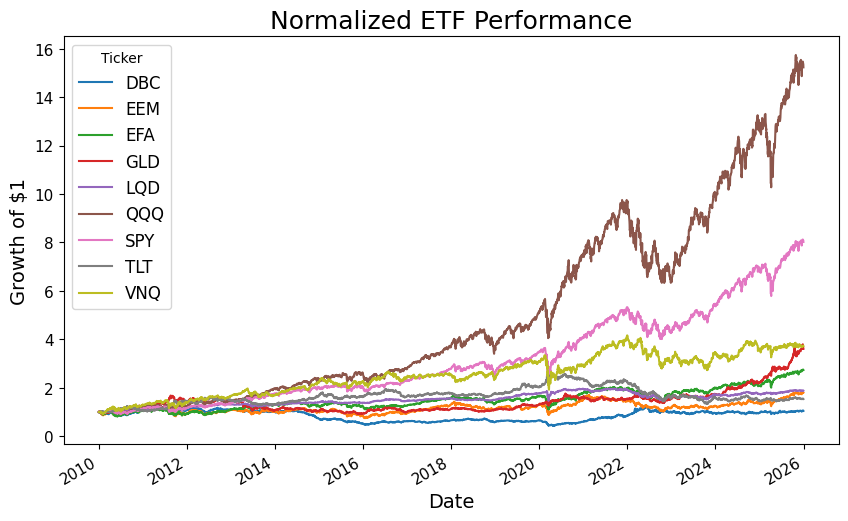

In [5]:
# Normalize all assets to start at 1
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(10, 6))

plt.title("Normalized ETF Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend(title="Ticker")
plt.show()

# 3. Risk and Return Analysis

Historical daily returns are used to estimate expected return, volatility, and cross-asset relationships. Correlation analysis helps identify diversification benefits across asset classes.

In [6]:
# Compute daily returns
returns = prices.pct_change().dropna()

returns.head()

Ticker,DBC,EEM,EFA,GLD,LQD,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2010-01-05,0.001189,0.007258,0.000882,-0.000911,0.004776,0.000000,0.002647,0.006457,-0.001122
2010-01-06,0.017808,0.002092,0.004227,0.016500,-0.002948,-0.006032,0.000704,-0.013386,-0.001798
2010-01-07,-0.012442,-0.005799,-0.003858,-0.006188,0.001240,0.000650,0.004221,0.001683,0.010806
2010-01-08,-0.000787,0.007933,0.007922,0.004963,0.002190,0.008231,0.003328,-0.000449,-0.007350
2010-01-11,-0.003152,-0.002083,0.008210,0.013289,0.001045,-0.004082,0.001396,-0.005487,0.005834


In [7]:
# Annualized return and volatility summary
summary_stats = pd.DataFrame({
    "Annualized Return": returns.mean() * 252,
    "Annualized Volatility": returns.std() * np.sqrt(252)
})

summary_stats.round(3)

,Annualized Return,Annualized Volatility
Ticker,,
DBC,0.018,0.171
EEM,0.060,0.213
EFA,0.080,0.184
GLD,0.093,0.158
LQD,0.043,0.077
QQQ,0.192,0.206
SPY,0.145,0.172
TLT,0.038,0.151
VNQ,0.103,0.205


### Asset Risk-Return Profile

The figure below compares the annualized return and volatility of each ETF, illustrating differences in historical risk and performance across asset classes.

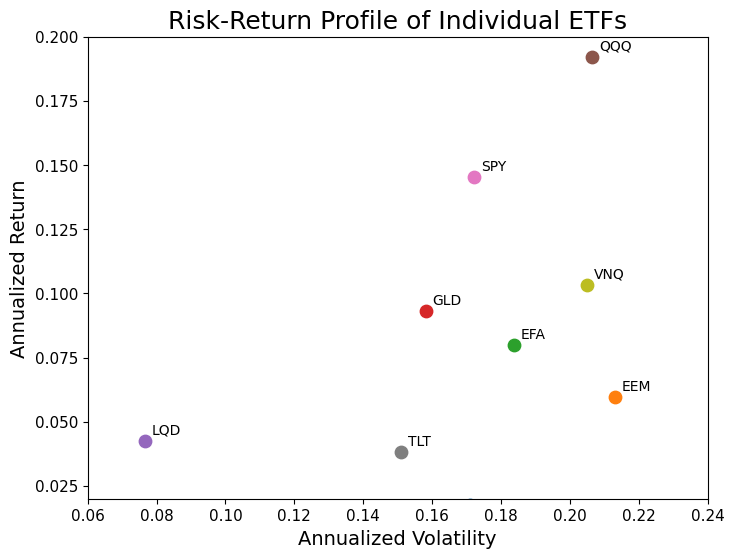

In [ ]:
plt.figure(figsize=(8, 6))

for ticker in summary_stats.index:
    plt.scatter(
        summary_stats.loc[ticker, "Annualized Volatility"],
        summary_stats.loc[ticker, "Annualized Return"],
        s=80
    )

    plt.annotate(
        ticker,
        (
            summary_stats.loc[ticker, "Annualized Volatility"],
            summary_stats.loc[ticker, "Annualized Return"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk-Return Profile of Individual ETFs")

plt.xlim(0.06, 0.24)
plt.ylim(0.02, 0.20)

plt.show()

QQQ produced the highest historical return but also had high volatility, while LQD had substantially lower return and risk. Combining assets with different risk-return profiles may improve portfolio diversification.

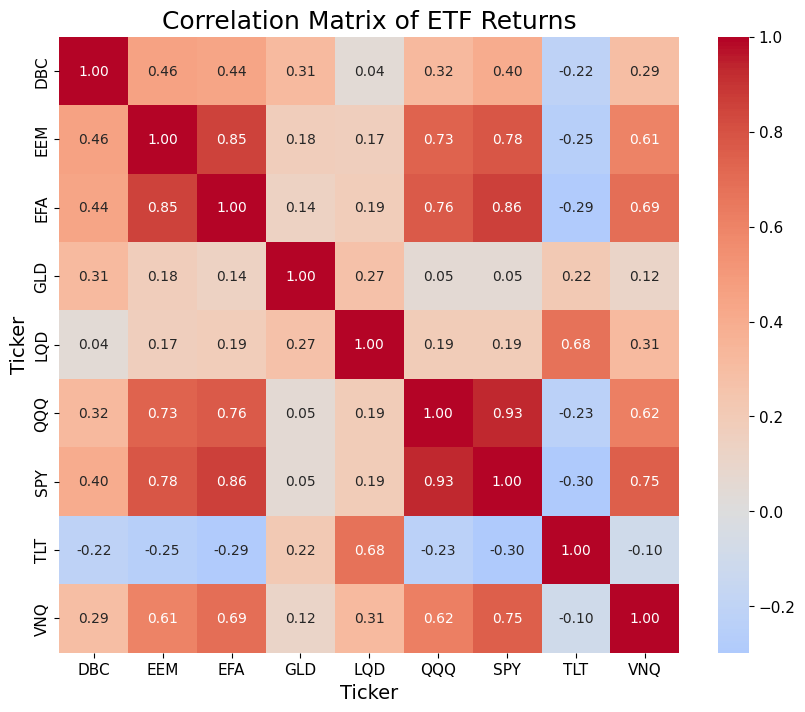

In [9]:
# Correlation matrix
corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Correlation Matrix of ETF Returns")
plt.show()

The correlation matrix highlights how different asset classes move relative to one another. Lower or negative correlations can reduce portfolio volatility because losses in one asset may be partially offset by gains or smaller losses in another.

# 4. Portfolio Theory

Portfolio performance depends on both asset weights and cross-asset relationships. Portfolio weights sum to 1, representing a fully invested portfolio. Expected return is determined by weighted asset returns, while portfolio risk also depends on the covariance between assets.

### Portfolio Return

The expected portfolio return is calculated as the weighted average of each asset's expected return:

$$
R_p = w^T \mu
$$

where $w$ is the vector of portfolio weights and $\mu$ is the vector of average asset returns.

In [10]:
def portfolio_return(weights, returns):
    """
    Compute expected daily portfolio return.
    
    weights: array of portfolio weights
    returns: DataFrame of daily asset returns
    """
    return returns.mean() @ weights

### Portfolio Volatility

Portfolio volatility measures the risk of the combined portfolio. Unlike return, volatility is not simply the weighted average of individual volatilities because asset co-movement matters.

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

where $\Sigma$ is the covariance matrix of asset returns.

In [11]:
def portfolio_volatility(weights, cov_matrix):
    """
    Compute daily portfolio volatility.
    
    weights: array of portfolio weights
    cov_matrix: covariance matrix of asset returns
    """
    return np.sqrt(weights.T @ cov_matrix @ weights)

### Equal-Weight Portfolio

As a baseline, an equal-weight portfolio allocates the same fraction of capital to each ETF. This provides a simple benchmark before applying optimization.

In [12]:
n_assets = len(returns.columns)

equal_weights = np.ones(n_assets) / n_assets
cov_matrix = returns.cov()

equal_return = portfolio_return(equal_weights, returns)
equal_volatility = portfolio_volatility(equal_weights, cov_matrix)

print("Equal-weight portfolio")
print("Expected daily return:", equal_return.round(6))
print("Daily volatility:", equal_volatility.round(6))

Equal-weight portfolio
Expected daily return: 0.00034
Daily volatility: 0.007063


### Diversification Effect

A weighted average of individual asset volatilities ignores covariance. When assets are not perfectly correlated, portfolio volatility can be lower than this naive estimate.

In [13]:
naive_volatility = (equal_weights * returns.std()).sum()
true_volatility = portfolio_volatility(equal_weights, cov_matrix)

portfolio_theory_summary = pd.DataFrame({
    "Metric": [
        "Expected Daily Return",
        "Naive Daily Volatility",
        "True Daily Volatility",
        "Diversification Benefit"
    ],
    "Value": [
        equal_return,
        naive_volatility,
        true_volatility,
        naive_volatility - true_volatility
    ]
})

portfolio_theory_summary = portfolio_theory_summary.set_index("Metric")
portfolio_theory_summary.index.name = None

portfolio_theory_summary.round(6)

,Value
Expected Daily Return,0.000340
Naive Daily Volatility,0.010758
True Daily Volatility,0.007063
Diversification Benefit,0.003695


The equal-weight portfolio's volatility is lower than the weighted average of individual asset volatilities, demonstrating the diversification benefit created by imperfect correlations.

# 5. Portfolio Optimization

## 5.1 Unconstrained Optimization

This section first examines unconstrained mean-variance optimization using classical Modern Portfolio Theory techniques. These unconstrained portfolios serve as a baseline for understanding how optimization behaves when allocations are determined purely by historical return and covariance estimates.

The analysis focuses on two classical optimization approaches:

- Minimum Variance Portfolio
- Maximum Sharpe Ratio Portfolio

The efficient frontier is then constructed to visualize the tradeoff between portfolio risk and expected return across feasible portfolios.

Portfolio optimization is performed using daily return estimates. Unless otherwise stated, reported portfolio performance metrics are annualized for ease of interpretation.

### Portfolio Constraints

The baseline portfolios are long-only and fully invested:

- Portfolio weights sum to 1
- Short selling is not allowed
- Individual weights range from 0% to 100%

Here, "unconstrained" refers to the absence of additional diversification bounds.

In [14]:
n_assets = len(returns.columns)

constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

bounds = [(0, 1)] * n_assets

initial_guess = np.ones(n_assets) / n_assets

### Minimum Variance Portfolio

The minimum variance portfolio identifies the allocation with the lowest possible portfolio volatility regardless of return expectations.

The optimization problem is:

$$
\min_w \sqrt{w^T \Sigma w}
$$

subject to the portfolio constraints.

In [15]:
cov_matrix = returns.cov()

min_var_result = minimize(
    portfolio_volatility,
    initial_guess,
    args=(cov_matrix,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

min_var_weights = min_var_result.x

In [16]:
min_var_return = portfolio_return(min_var_weights, returns)
min_var_volatility = portfolio_volatility(min_var_weights, cov_matrix)

min_var_summary = pd.DataFrame({
    "Ticker": returns.columns,
    "Weight": min_var_weights
})

min_var_summary["Weight"] = min_var_summary["Weight"].round(4)
min_var_summary

,Ticker,Weight
0,DBC,0.1122
1,EEM,0.0000
2,EFA,0.0000
3,GLD,0.0567
4,LQD,0.7793
5,QQQ,0.0000
6,SPY,0.0518
7,TLT,0.0000
8,VNQ,0.0000


In [17]:
annual_min_var_return = min_var_return * 252
annual_min_var_volatility = min_var_volatility * np.sqrt(252)
annual_min_var_sharpe = annual_min_var_return / annual_min_var_volatility

print("Minimum Variance Portfolio")
print(f"Expected Annual Return: {annual_min_var_return:.2%}")
print(f"Annualized Volatility: {annual_min_var_volatility:.2%}")
print(f"Annualized Sharpe Ratio: {annual_min_var_sharpe:.2f}")

Minimum Variance Portfolio
Expected Annual Return: 4.79%
Annualized Volatility: 7.03%
Annualized Sharpe Ratio: 0.68


The minimum variance portfolio heavily allocates to LQD because the objective only minimizes volatility. It does not try to maximize return, so it favors stable bond exposure over higher-return but more volatile assets.

### Maximum Sharpe Ratio Portfolio

The Sharpe ratio measures return earned per unit of risk:

$$
\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}
$$

For simplicity, the risk-free rate is assumed to be zero in this analysis.

The maximum Sharpe portfolio seeks the allocation with the highest risk-adjusted return.

In [18]:
def negative_sharpe(weights, returns, cov_matrix):
    
    port_return = portfolio_return(weights, returns)
    port_volatility = portfolio_volatility(weights, cov_matrix)
    
    return -(port_return / port_volatility)

In [19]:
max_sharpe_result = minimize(
    negative_sharpe,
    initial_guess,
    args=(returns, cov_matrix),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = max_sharpe_result.x

In [20]:
max_sharpe_return = portfolio_return(max_sharpe_weights, returns)
max_sharpe_volatility = portfolio_volatility(max_sharpe_weights, cov_matrix)

max_sharpe_summary = pd.DataFrame({
    "Ticker": returns.columns,
    "Weight": max_sharpe_weights
})

max_sharpe_summary["Weight"] = max_sharpe_summary["Weight"].round(4)
max_sharpe_summary

,Ticker,Weight
0,DBC,0.0000
1,EEM,0.0000
2,EFA,0.0000
3,GLD,0.2743
4,LQD,0.0000
5,QQQ,0.4392
6,SPY,0.0369
7,TLT,0.2496
8,VNQ,0.0000


In [21]:
annual_max_sharpe_return = max_sharpe_return * 252
annual_max_sharpe_volatility = max_sharpe_volatility * np.sqrt(252)
annual_max_sharpe_ratio = annual_max_sharpe_return / annual_max_sharpe_volatility

print("Maximum Sharpe Portfolio")
print("Expected Annual Return:", round(annual_max_sharpe_return * 100, 2), "%")
print("Annualized Volatility:", round(annual_max_sharpe_volatility * 100, 2), "%")
print("Annualized Sharpe Ratio:", round(annual_max_sharpe_ratio, 2))

Maximum Sharpe Portfolio
Expected Annual Return: 12.47 %
Annualized Volatility: 10.99 %
Annualized Sharpe Ratio: 1.14


The maximum Sharpe portfolio is concentrated in QQQ, GLD, and TLT, while several ETFs receive near-zero weights. The result shows how historical mean-variance optimization can produce concentrated allocations when estimated risk-adjusted returns differ across assets.

### Efficient Frontier

The efficient frontier represents the set of portfolios that achieve the highest expected return for each level of risk.

For a target return level, the optimization problem minimizes portfolio volatility subject to achieving the desired return.

In [22]:
target_returns = np.linspace(
    returns.mean().min(),
    returns.mean().max(),
    50
)

frontier_returns = []
frontier_volatilities = []

In [23]:
for target_return in target_returns:

    frontier_constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        },
        {
            "type": "eq",
            "fun": lambda w, target_return=target_return:
            portfolio_return(w, returns) - target_return
        }
    ]

    result = minimize(
        portfolio_volatility,
        initial_guess,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=frontier_constraints
    )

    if result.success:
        frontier_returns.append(
            portfolio_return(result.x, returns)
        )

        frontier_volatilities.append(
            portfolio_volatility(result.x, cov_matrix)
        )

In [24]:
frontier_returns = np.array(frontier_returns)
frontier_volatilities = np.array(frontier_volatilities)

# Keep only efficient (upper) frontier
min_var_idx = np.argmin(frontier_volatilities)

frontier_returns = frontier_returns[min_var_idx:]
frontier_volatilities = frontier_volatilities[min_var_idx:]

To visualize the feasible portfolio space, thousands of random portfolios are generated by randomly assigning portfolio weights subject to the portfolio constraints.

In [25]:
n_random_portfolios = 30000

random_returns = []
random_volatilities = []
random_sharpes = []

for _ in range(n_random_portfolios):

    weights = np.random.random(n_assets)
    weights /= weights.sum()

    port_return = portfolio_return(weights, returns)
    port_volatility = portfolio_volatility(weights, cov_matrix)

    random_returns.append(port_return)
    random_volatilities.append(port_volatility)
    random_sharpes.append(port_return / port_volatility)

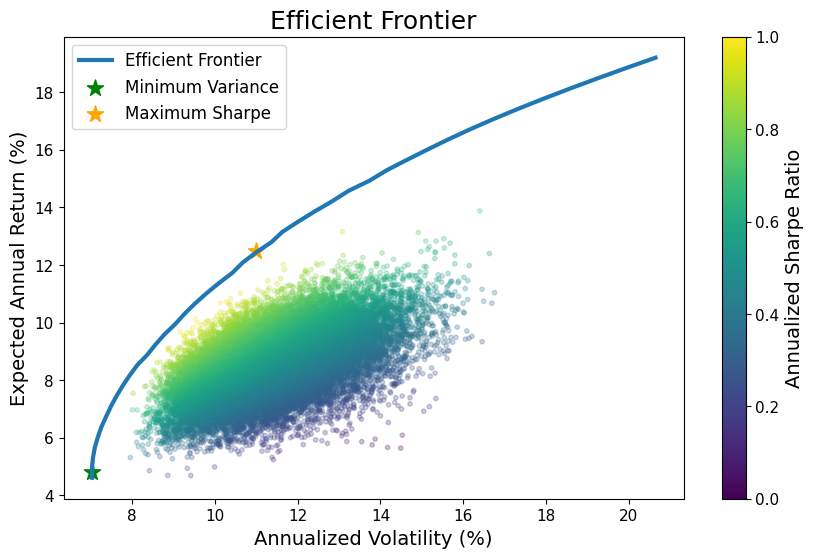

In [26]:
random_volatilities = np.array(random_volatilities)
random_returns = np.array(random_returns)
random_sharpes = np.array(random_sharpes)

frontier_volatilities = np.array(frontier_volatilities)
frontier_returns = np.array(frontier_returns)


plt.scatter(
    random_volatilities * np.sqrt(252) * 100,
    random_returns * 252 * 100,
    c=random_sharpes * np.sqrt(252),
    cmap="viridis",
    alpha=0.25,
    s=10
)

plt.plot(
    frontier_volatilities * np.sqrt(252) * 100,
    frontier_returns * 252 * 100,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    min_var_volatility * np.sqrt(252) * 100,
    min_var_return * 252 * 100,
    s=150,
    marker="*",
    color="green",
    label="Minimum Variance"
)

plt.scatter(
    max_sharpe_volatility * np.sqrt(252) * 100,
    max_sharpe_return * 252 * 100,
    s=150,
    marker="*",
    color="orange",
    label="Maximum Sharpe"
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Efficient Frontier")

plt.colorbar(label="Annualized Sharpe Ratio")
plt.legend()
plt.show()

The random portfolios illustrate the feasible risk-return space, while the efficient frontier identifies the highest expected return available at each level of volatility. The minimum variance portfolio lies at the lowest-risk point, while the maximum Sharpe portfolio identifies the strongest estimated risk-adjusted allocation.

## 5.2 Constrained Optimization

Additional allocation bounds are introduced to limit concentration:

- Minimum asset weight: 5%
- Maximum asset weight: 35%

The constrained portfolios are compared with the baseline solutions to measure the cost of greater diversification.

In [27]:
bounds_constrained = [(0.05, 0.35)] * n_assets

### Constrained Minimum Variance

In [28]:
constrained_min_var_result = minimize(
    portfolio_volatility,
    initial_guess,
    args=(cov_matrix,),
    method="SLSQP",
    bounds=bounds_constrained,
    constraints=constraints
)

constrained_min_var_weights = constrained_min_var_result.x

constrained_min_var_return = portfolio_return(
    constrained_min_var_weights,
    returns
)

constrained_min_var_volatility = portfolio_volatility(
    constrained_min_var_weights,
    cov_matrix
)

constrained_min_var_summary = pd.DataFrame({
    "Ticker": returns.columns,
    "Weight": constrained_min_var_weights.round(4)
})

constrained_min_var_summary

,Ticker,Weight
0,DBC,0.1188
1,EEM,0.0500
2,EFA,0.0500
3,GLD,0.0510
4,LQD,0.3500
5,QQQ,0.0500
6,SPY,0.0500
7,TLT,0.2302
8,VNQ,0.0500


The constrained minimum variance portfolio remains relatively defensive but is forced to diversify more broadly across the ETF universe due to the allocation bounds.

In [29]:
annual_constrained_min_var_return = constrained_min_var_return * 252
annual_constrained_min_var_volatility = constrained_min_var_volatility * np.sqrt(252)
annual_constrained_min_var_sharpe = (
    annual_constrained_min_var_return /
    annual_constrained_min_var_volatility
)

print("Constrained Minimum Variance Portfolio")
print(f"Expected Annual Return: {annual_constrained_min_var_return:.2%}")
print(f"Annualized Volatility: {annual_constrained_min_var_volatility:.2%}")
print(f"Annualized Sharpe Ratio: {annual_constrained_min_var_sharpe:.2f}")

Constrained Minimum Variance Portfolio
Expected Annual Return: 5.96%
Annualized Volatility: 7.93%
Annualized Sharpe Ratio: 0.75


Compared with the unconstrained minimum variance portfolio, the constrained solution accepts slightly higher volatility in exchange for broader diversification across the ETF universe. This illustrates the tradeoff between minimizing risk as aggressively as possible and maintaining a more balanced allocation.

### Constrained Maximum Sharpe

In [30]:
constrained_max_sharpe_result = minimize(
    negative_sharpe,
    initial_guess,
    args=(returns, cov_matrix),
    method="SLSQP",
    bounds=bounds_constrained,
    constraints=constraints
)

constrained_max_sharpe_weights = constrained_max_sharpe_result.x

constrained_max_sharpe_return = portfolio_return(
    constrained_max_sharpe_weights,
    returns
)

constrained_max_sharpe_volatility = portfolio_volatility(
    constrained_max_sharpe_weights,
    cov_matrix
)

constrained_max_sharpe_summary = pd.DataFrame({
    "Ticker": returns.columns,
    "Weight": constrained_max_sharpe_weights.round(4)
})

constrained_max_sharpe_summary

,Ticker,Weight
0,DBC,0.0500
1,EEM,0.0500
2,EFA,0.0500
3,GLD,0.2075
4,LQD,0.0500
5,QQQ,0.2992
6,SPY,0.0500
7,TLT,0.1933
8,VNQ,0.0500


Compared to the unconstrained solution, the constrained maximum Sharpe portfolio distributes capital more evenly across assets and avoids extreme concentration in a small subset of ETFs.

In [31]:
annual_constrained_max_sharpe_return = constrained_max_sharpe_return * 252
annual_constrained_max_sharpe_volatility = (
    constrained_max_sharpe_volatility * np.sqrt(252)
)
annual_constrained_max_sharpe_ratio = (
    annual_constrained_max_sharpe_return /
    annual_constrained_max_sharpe_volatility
)

print("Constrained Maximum Sharpe Portfolio")
print(f"Expected Annual Return: {annual_constrained_max_sharpe_return:.2%}")
print(f"Annualized Volatility: {annual_constrained_max_sharpe_volatility:.2%}")
print(f"Annualized Sharpe Ratio: {annual_constrained_max_sharpe_ratio:.2f}")

Constrained Maximum Sharpe Portfolio
Expected Annual Return: 10.65%
Annualized Volatility: 10.63%
Annualized Sharpe Ratio: 1.00


Compared with the unconstrained maximum Sharpe portfolio, the constrained solution sacrifices some risk-adjusted performance in exchange for a more diversified allocation. This reflects the practical tradeoff between maximizing historical efficiency and limiting concentration risk.

### Constrained Efficient Frontier

The efficient frontier can also be constructed under the allocation constraints introduced above. Comparing the constrained and unconstrained frontiers illustrates the cost of imposing diversification requirements.

Because the optimizer has less flexibility, the constrained frontier generally lies below the unconstrained frontier, indicating a modest reduction in achievable return for a given level of risk.

In [32]:
constrained_target_returns = np.linspace(
    constrained_min_var_return,
    constrained_max_sharpe_return * 1.5,
    50
)

constrained_frontier_returns = []
constrained_frontier_volatilities = []

for target_return in constrained_target_returns:

    frontier_constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        },
        {
            "type": "eq",
            "fun": lambda w, target_return=target_return:
            portfolio_return(w, returns) - target_return
        }
    ]

    result = minimize(
        portfolio_volatility,
        initial_guess,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds_constrained,
        constraints=frontier_constraints
    )

    if result.success:

        constrained_frontier_returns.append(
            portfolio_return(result.x, returns)
        )

        constrained_frontier_volatilities.append(
            portfolio_volatility(result.x, cov_matrix)
        )

constrained_frontier_returns = np.array(
    constrained_frontier_returns
)

constrained_frontier_volatilities = np.array(
    constrained_frontier_volatilities
)

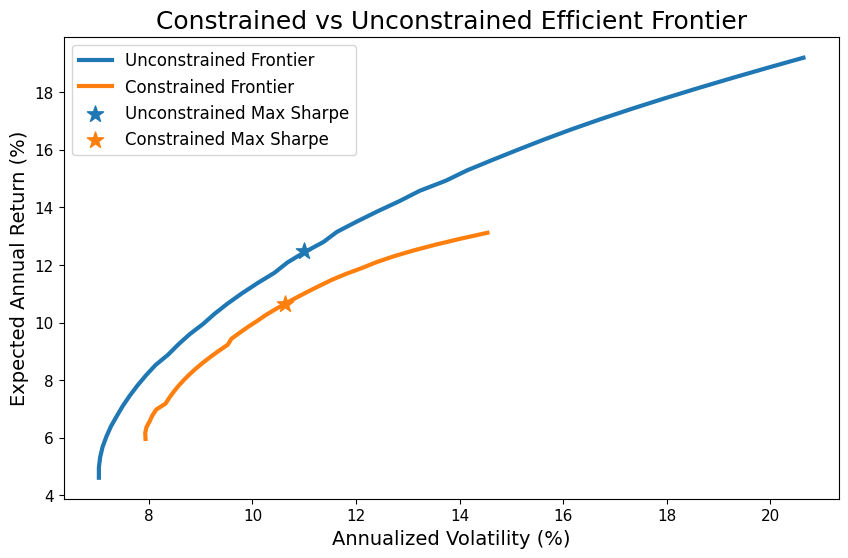

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    np.array(frontier_volatilities) * np.sqrt(252) * 100,
    np.array(frontier_returns) * 252 * 100,
    linewidth=3,
    label="Unconstrained Frontier"
)

plt.plot(
    np.array(constrained_frontier_volatilities) * np.sqrt(252) * 100,
    np.array(constrained_frontier_returns) * 252 * 100,
    linewidth=3,
    label="Constrained Frontier"
)

plt.scatter(
    max_sharpe_volatility * np.sqrt(252) * 100,
    max_sharpe_return * 252 * 100,
    s=150,
    marker="*",
    label="Unconstrained Max Sharpe"
)

plt.scatter(
    constrained_max_sharpe_volatility * np.sqrt(252) * 100,
    constrained_max_sharpe_return * 252 * 100,
    s=150,
    marker="*",
    label="Constrained Max Sharpe"
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Constrained vs Unconstrained Efficient Frontier")

plt.legend()
plt.show()

The constrained frontier lies below the baseline frontier because the optimizer has less flexibility. The allocation bounds reduce estimated in-sample efficiency but prevent the most concentrated portfolio solutions.

### Optimization Comparison

In [34]:
optimization_comparison = pd.DataFrame({
    "Portfolio": [
        "Unconstrained Min Variance",
        "Constrained Min Variance",
        "Unconstrained Max Sharpe",
        "Constrained Max Sharpe"
    ],

    "Annualized Return (%)": [
        min_var_return * 252 * 100,
        constrained_min_var_return * 252 * 100,
        max_sharpe_return * 252 * 100,
        constrained_max_sharpe_return * 252 * 100
    ],

    "Annualized Volatility (%)": [
        min_var_volatility * np.sqrt(252) * 100,
        constrained_min_var_volatility * np.sqrt(252) * 100,
        max_sharpe_volatility * np.sqrt(252) * 100,
        constrained_max_sharpe_volatility * np.sqrt(252) * 100
    ],

    "Sharpe Ratio": [
        (min_var_return * 252) / (min_var_volatility * np.sqrt(252)),
        (constrained_min_var_return * 252) / (constrained_min_var_volatility * np.sqrt(252)),
        (max_sharpe_return * 252) / (max_sharpe_volatility * np.sqrt(252)),
        (constrained_max_sharpe_return * 252) / (constrained_max_sharpe_volatility * np.sqrt(252))
    ]
})

optimization_comparison = optimization_comparison.set_index("Portfolio")
optimization_comparison.index.name = None

optimization_comparison.round(2)

,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio
Unconstrained Min Variance,4.79,7.03,0.68
Constrained Min Variance,5.96,7.93,0.75
Unconstrained Max Sharpe,12.47,10.99,1.14
Constrained Max Sharpe,10.65,10.63,1.00


The allocation constraints reduce the maximum Sharpe ratio from 1.14 to 1.00 but produce a more diversified portfolio. The constrained minimum variance portfolio similarly accepts higher volatility in exchange for less concentrated weights.

These results show the in-sample cost of diversification constraints. Whether the more diversified allocations are also more stable is evaluated later using rolling out-of-sample testing and bootstrap resampling.

# 6. Portfolio Performance Evaluation

Performance evaluation uses realized compounded returns, which may differ slightly from the annualized expected returns reported in the optimization section.

## 6.1 Performance Metrics

In [35]:
def annualized_return(port_returns, periods_per_year=252):
    growth = (1 + port_returns).prod()
    n_periods = len(port_returns)

    return growth ** (periods_per_year / n_periods) - 1


def annualized_volatility(port_returns, periods_per_year=252):
    return port_returns.std() * np.sqrt(periods_per_year)


def sharpe_ratio(port_returns, risk_free_rate=0, periods_per_year=252):
    ann_return = annualized_return(port_returns, periods_per_year)
    ann_volatility = annualized_volatility(port_returns, periods_per_year)

    return (ann_return - risk_free_rate) / ann_volatility


def max_drawdown(port_returns):
    cumulative = (1 + port_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1

    return drawdown.min()

In [36]:
portfolio_return_series = {
    "Equal Weight": returns @ equal_weights,
    "Unconstrained Min Variance": returns @ min_var_weights,
    "Constrained Min Variance": returns @ constrained_min_var_weights,
    "Unconstrained Max Sharpe": returns @ max_sharpe_weights,
    "Constrained Max Sharpe": returns @ constrained_max_sharpe_weights,
    "SPY Benchmark": returns["SPY"]
}

In [37]:
performance_summary = []

for name, port_returns in portfolio_return_series.items():

    performance_summary.append({
        "Portfolio": name,
        "Annualized Return (%)": annualized_return(port_returns) * 100,
        "Annualized Volatility (%)": annualized_volatility(port_returns) * 100,
        "Sharpe Ratio": sharpe_ratio(port_returns),
        "Maximum Drawdown (%)": max_drawdown(port_returns) * 100
    })

performance_summary = pd.DataFrame(performance_summary)

performance_summary = performance_summary.set_index("Portfolio")
performance_summary.index.name = None

performance_summary.round(2)

,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
Equal Weight,8.27,11.21,0.74,-22.85
Unconstrained Min Variance,4.65,7.03,0.66,-20.56
Constrained Min Variance,5.80,7.93,0.73,-22.87
Unconstrained Max Sharpe,12.60,10.99,1.15,-27.48
Constrained Max Sharpe,10.61,10.63,1.00,-24.70
SPY Benchmark,13.93,17.21,0.81,-33.72


The unconstrained maximum Sharpe portfolio has the strongest risk-adjusted performance among the optimized portfolios, but also a larger drawdown than the minimum variance and equal-weight portfolios.

SPY produces the highest return, but also the highest volatility and deepest drawdown. The constrained portfolios generally trade some in-sample efficiency for broader diversification.

## 6.2 Cumulative Portfolio Performance

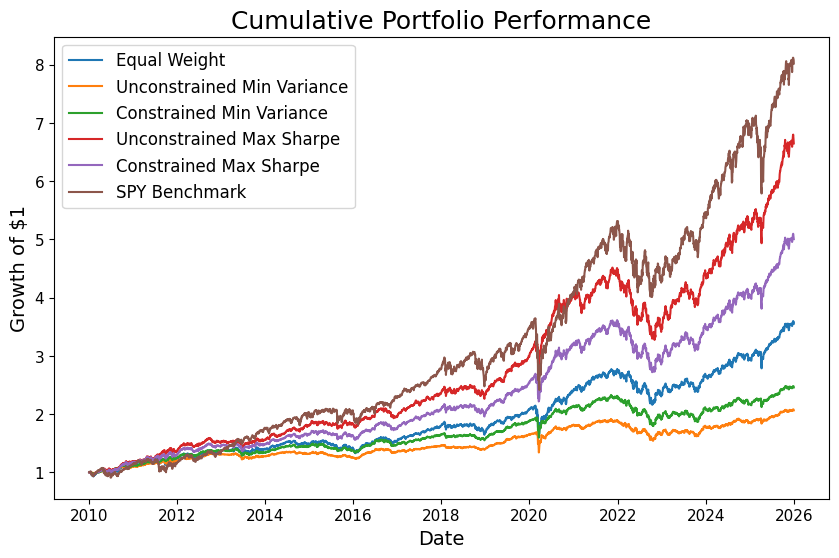

In [38]:
plt.figure(figsize=(10, 6))

for name, port_returns in portfolio_return_series.items():

    cumulative_returns = (1 + port_returns).cumprod()

    plt.plot(
        cumulative_returns,
        label=name
    )

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Cumulative Portfolio Performance")

plt.legend()
plt.show()

SPY achieves the highest cumulative growth, while the unconstrained maximum Sharpe portfolio performs best among the optimized portfolios. The minimum variance portfolios grow more slowly but experience smaller fluctuations.

These results are in-sample because the portfolio weights were estimated using the full historical dataset. The next section evaluates the strategy using a rolling out-of-sample backtest.

# 7. Rolling Out-of-Sample Backtest

The previous section evaluates static portfolios estimated using the full historical sample. This section instead uses a rolling out-of-sample backtest.

At each rebalance date, expected returns and covariance are estimated using a two-year lookback window. A constrained maximum Sharpe portfolio is then formed and applied over the following 21 trading days before re-optimization.

## 7.1 Rolling Constrained Maximum Sharpe Portfolio

In [39]:
# Extended data for rolling backtest
backtest_prices = yf.download(
    tickers,
    start="2008-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"].dropna()

backtest_returns = backtest_prices.pct_change().dropna()



[*********************100%***********************]  9 of 9 completed


In [40]:
evaluation_start = "2010-01-01"
window = 252 * 2
rebalance_freq = 21

rolling_returns_list = []
rolling_weights = []
rebalance_dates = []

start_idx = backtest_returns.index.searchsorted(evaluation_start)

for i in range(start_idx, len(backtest_returns), rebalance_freq):

    if i < window:
        continue

    past_returns = backtest_returns.iloc[i-window:i]
    past_cov = past_returns.cov()

    result = minimize(
        negative_sharpe,
        initial_guess,
        args=(past_returns, past_cov),
        method="SLSQP",
        bounds=bounds_constrained,
        constraints=constraints
    )

    if result.success:
        weights = result.x

        future_returns = backtest_returns.iloc[
            i:min(i + rebalance_freq, len(backtest_returns))
        ]

        port_returns = future_returns @ weights

        rolling_returns_list.append(port_returns)
        rolling_weights.append(weights)
        rebalance_dates.append(backtest_returns.index[i])

In [41]:
rolling_returns = pd.concat(rolling_returns_list)

rolling_weights_df = pd.DataFrame(
    rolling_weights,
    index=rebalance_dates,
    columns=backtest_returns.columns
)

evaluation_index = rolling_returns.index

equal_weight_returns = (
    backtest_returns.loc[evaluation_index] @ equal_weights
)

spy_returns = backtest_returns.loc[evaluation_index, "SPY"]

In [42]:
rolling_performance = {
    "Rolling Constrained Max Sharpe": rolling_returns,
    "Equal Weight": equal_weight_returns,
    "SPY Benchmark": spy_returns
}

rolling_summary = []

for name, port_returns in rolling_performance.items():

    rolling_summary.append({
        "Portfolio": name,
        "Annualized Return (%)": annualized_return(port_returns) * 100,
        "Annualized Volatility (%)": annualized_volatility(port_returns) * 100,
        "Sharpe Ratio": sharpe_ratio(port_returns),
        "Maximum Drawdown (%)": max_drawdown(port_returns) * 100
    })

rolling_summary = pd.DataFrame(rolling_summary)

rolling_summary = rolling_summary.set_index("Portfolio")
rolling_summary.index.name = None

rolling_summary.round(2)

,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
Rolling Constrained Max Sharpe,8.97,9.99,0.90,-19.60
Equal Weight,8.37,11.22,0.75,-22.85
SPY Benchmark,14.05,17.21,0.82,-33.72


The rolling strategy improves on equal weight, increasing the Sharpe ratio from 0.75 to 0.90 while reducing maximum drawdown from 22.85% to 19.60%. SPY produces the highest return but also has the highest volatility and deepest drawdown.

## 7.2 Out-of-Sample Cumulative Performance

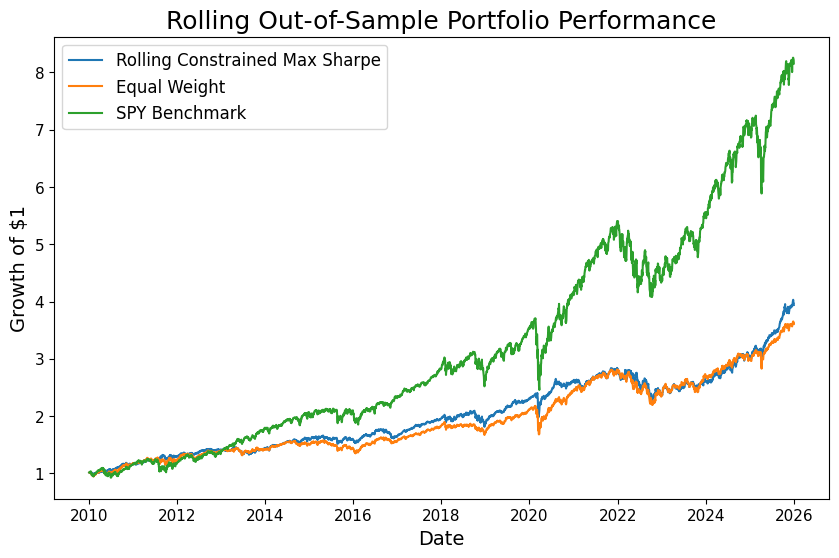

In [43]:
plt.figure(figsize=(10, 6))

for name, port_returns in rolling_performance.items():

    cumulative_returns = (1 + port_returns).cumprod()

    plt.plot(
        cumulative_returns,
        label=name
    )

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Rolling Out-of-Sample Portfolio Performance")

plt.legend()
plt.show()

SPY produces the highest cumulative growth, while the rolling strategy tracks the equal-weight portfolio more closely. The rolling strategy nevertheless outperforms equal weight on a risk-adjusted basis and experiences a smaller maximum drawdown.

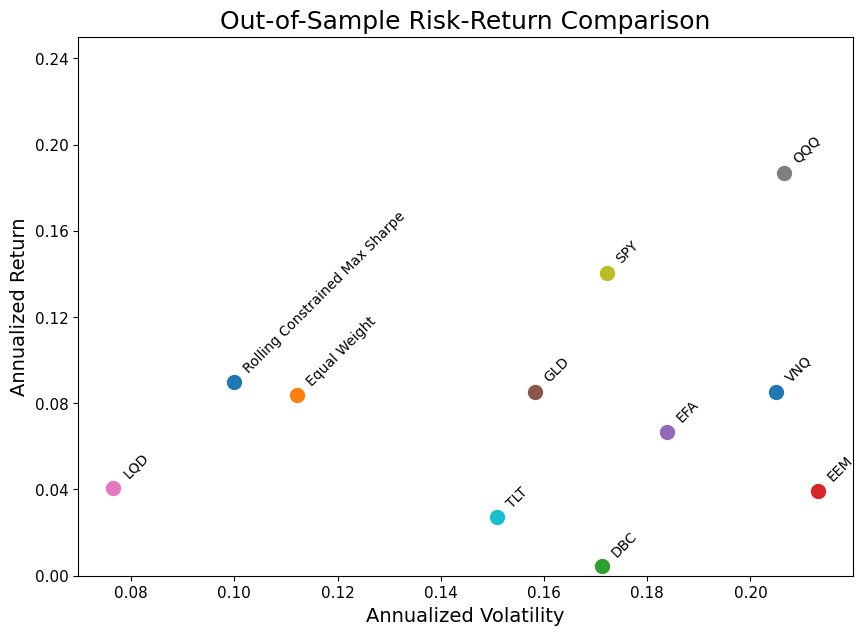

In [55]:
comparison_returns = {
    "Rolling Constrained Max Sharpe": rolling_returns,
    "Equal Weight": equal_weight_returns
}

for ticker in backtest_returns.columns:
    comparison_returns[ticker] = backtest_returns.loc[evaluation_index, ticker]

plt.figure(figsize=(10, 7))

for name, asset_returns in comparison_returns.items():

    ann_return = annualized_return(asset_returns)
    ann_vol = annualized_volatility(asset_returns)

    plt.scatter(
        ann_vol,
        ann_return,
        s=100
    )

    plt.annotate(
        name,
        (ann_vol, ann_return),
        xytext=(5, 5),
        textcoords="offset points",
        rotation=45,
        ha="left",
        va="bottom"
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Out-of-Sample Risk-Return Comparison")

plt.ylim(0.05, 0.25)
plt.yticks(np.arange(0, 0.241, 0.04))

plt.show()

The rolling strategy delivers slightly higher return and lower volatility than the equal-weight portfolio. It also has substantially lower volatility than the major equity ETFs in the sample.

## 7.3 Rolling Portfolio Weights

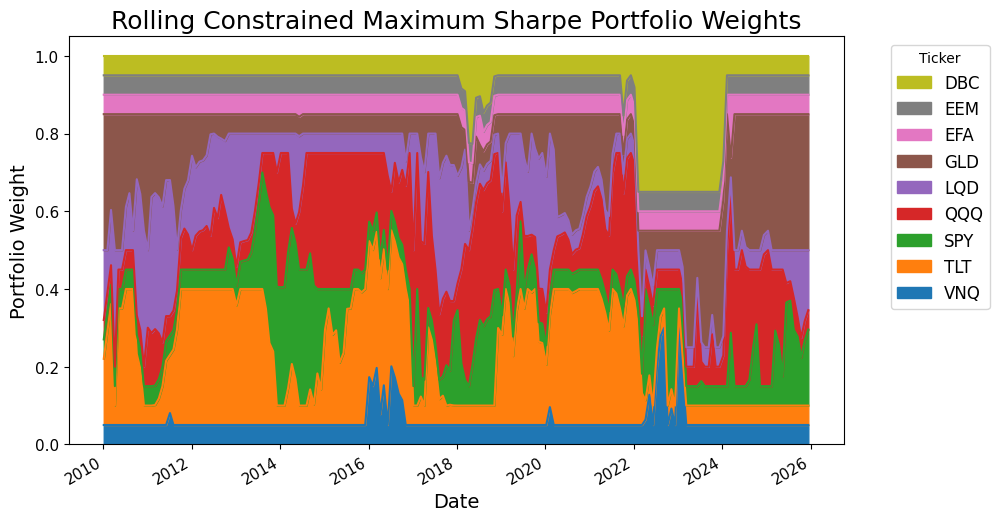

In [45]:
ax = rolling_weights_df[rolling_weights_df.columns[::-1]].plot.area(
    figsize=(10, 6),
    stacked=True
)

plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.title("Rolling Constrained Maximum Sharpe Portfolio Weights")

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[::-1],
    labels[::-1],
    title="Ticker",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

Portfolio weights vary substantially over time, with several assets frequently reaching the 5% or 35% allocation bounds. The constraints limit concentration but do not eliminate sensitivity to changing return and covariance estimates.

The bootstrap analysis in the next section tests this estimation sensitivity more directly.

# 8. Bootstrap Stability Analysis

Bootstrap resampling is used to test how sensitive the optimized portfolio weights are to changes in the historical return sample. Maximum Sharpe portfolios are re-estimated under both baseline and constrained allocation rules.

In [46]:
n_bootstrap = 300

unconstrained_bootstrap_weights = []
constrained_bootstrap_weights = []

rng = np.random.default_rng(42)

for _ in range(n_bootstrap):

    sample_indices = rng.integers(
        0,
        len(returns),
        size=len(returns)
    )

    sample_returns = returns.iloc[sample_indices]
    sample_cov = sample_returns.cov()

    # Unconstrained maximum Sharpe portfolio
    unconstrained_result = minimize(
        negative_sharpe,
        initial_guess,
        args=(sample_returns, sample_cov),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if unconstrained_result.success:
        unconstrained_bootstrap_weights.append(
            unconstrained_result.x
        )

    # Constrained maximum Sharpe portfolio
    constrained_result = minimize(
        negative_sharpe,
        initial_guess,
        args=(sample_returns, sample_cov),
        method="SLSQP",
        bounds=bounds_constrained,
        constraints=constraints
    )

    if constrained_result.success:
        constrained_bootstrap_weights.append(
            constrained_result.x
        )

In [47]:
unconstrained_bootstrap_df = pd.DataFrame(
    unconstrained_bootstrap_weights,
    columns=returns.columns
)

constrained_bootstrap_df = pd.DataFrame(
    constrained_bootstrap_weights,
    columns=returns.columns
)

## 8.1 Bootstrap Weight Distributions

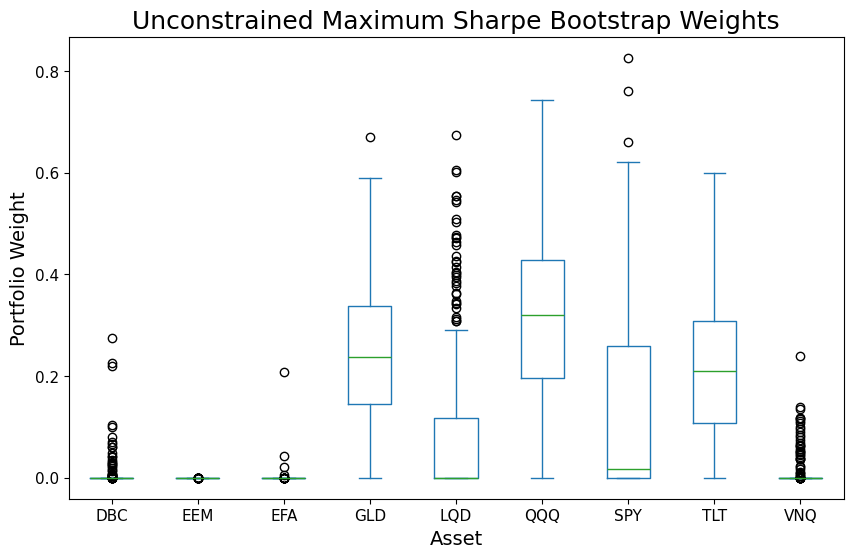

In [48]:
unconstrained_bootstrap_df.plot(
    kind="box",
    figsize=(10, 6)
)

plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.title("Unconstrained Maximum Sharpe Bootstrap Weights")

plt.show()

QQQ, GLD, and TLT receive the largest typical allocations, while several assets have median weights near zero. The wide weight distributions, particularly for SPY and LQD, show that small changes in the sampled data can produce large shifts in the optimized portfolio.

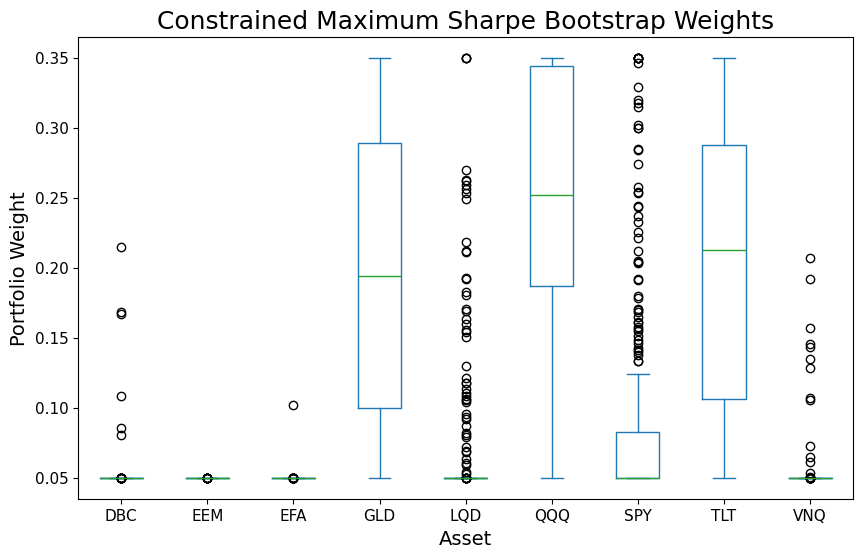

In [49]:
constrained_bootstrap_df.plot(
    kind="box",
    figsize=(10, 6)
)

plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.title("Constrained Maximum Sharpe Bootstrap Weights")

plt.show()

The 5% to 35% allocation bounds mechanically limit extreme portfolio weights. QQQ, GLD, and TLT still receive the largest typical allocations, while several other assets remain near the lower bound.

The constrained distributions are narrower for many assets, indicating that estimation error produces less extreme changes in the final portfolio allocation.

## 8.2 Bootstrap Weight Stability

In [50]:
bootstrap_stability = pd.DataFrame({
    "Unconstrained Mean Weight":
        unconstrained_bootstrap_df.mean(),

    "Unconstrained Weight Std":
        unconstrained_bootstrap_df.std(),

    "Constrained Mean Weight":
        constrained_bootstrap_df.mean(),

    "Constrained Weight Std":
        constrained_bootstrap_df.std()
})

bootstrap_stability.round(3)

,Unconstrained Mean Weight,Unconstrained Weight Std,Constrained Mean Weight,Constrained Weight Std
Ticker,,,,
DBC,0.005,0.027,0.052,0.014
EEM,0.000,0.000,0.050,0.000
EFA,0.001,0.012,0.050,0.003
GLD,0.245,0.139,0.196,0.105
LQD,0.083,0.149,0.067,0.051
QQQ,0.313,0.175,0.246,0.095
SPY,0.134,0.179,0.086,0.074
TLT,0.210,0.137,0.199,0.101
VNQ,0.008,0.027,0.053,0.018


The constrained portfolio has lower bootstrap weight standard deviations for most assets, with the largest reductions for LQD and SPY. QQQ, GLD, and TLT also become less variable.

The constraints do not remove estimation sensitivity, but they prevent it from producing such extreme portfolio positions.

# 9. Conclusion

This project applied mean-variance portfolio optimization across a diversified ETF universe and tested how allocation constraints affect performance and stability.

In-sample optimization produced concentrated maximum Sharpe portfolios. Adding 5% to 35% allocation bounds reduced concentration at the cost of some estimated in-sample efficiency.

In the rolling out-of-sample backtest, the constrained maximum Sharpe strategy improved on equal weight, increasing the Sharpe ratio from 0.75 to 0.90 while reducing maximum drawdown from 22.85% to 19.60%. SPY produced the highest absolute return, but with substantially higher volatility and downside risk.

Bootstrap resampling showed that optimized weights remain sensitive to estimation error. Allocation constraints reduced weight variability for most assets and limited extreme portfolio shifts.

The main result is that unconstrained optimization can produce unstable and concentrated portfolios, while simple allocation bounds can make the resulting portfolio more diversified and less sensitive to estimation error.

The analysis does not include transaction costs, taxes, or a nonzero risk-free rate. The rolling strategy also relies on historical return and covariance estimates, and the bootstrap assumes independently resampled daily returns. Possible extensions include transaction costs, covariance shrinkage, alternative expected-return models, and block bootstrap methods.